# Mini-project
## Introduction
On Day 5, you will apply the concepts learned in previous lessons to complete two hands-on projects: one involving image classification and the other focusing on text classification. These projects will help you solidify your understanding of preprocessing data, building and training neural networks, and evaluating model performance. By the end of the day, you will have created two functional models and gained practical experience in handling real-world datasets.



### 👩‍🏫 👩🏿‍🏫 What You’ll learn

## Daily Challenge: Image Classification with Data Augmentation (Cats vs Dogs)
How to preprocess image data for a convolutional neural network (CNN).
How to apply data augmentation techniques to improve model generalization.
How to build and train a CNN for binary image classification.
How to use dropout to reduce overfitting in a neural network.


## Mini-Project: Binary Text Classification with IMDB Dataset (CNN)
How to preprocess text data for neural networks.
How to build and train a simple feedforward neural network for binary classification.
How to evaluate the performance of a model using validation and test data.
How to visualize training and validation metrics to detect overfitting.


### 🛠️ What you will create

## Daily Challenge: Image Classification with Data Augmentation (Cats vs Dogs)
A binary image classification model to distinguish between images of cats and dogs.
A visualization of training and validation metrics to analyze model performance.


## Mini-Project: Binary Text Classification with IMDB Dataset (CNN)
A binary text classification model using the IMDB dataset to classify movie reviews as positive or negative.
A visualization of training and validation loss and accuracy to analyze model performance.


## Conclusion
By completing these projects, you will gain hands-on experience in building and training neural networks for both image and text classification tasks. You will also learn how to preprocess data, apply techniques like data augmentation and dropout to improve model performance, and evaluate your models using validation and test sets. These skills are essential for tackling real-world machine learning problems and will serve as a strong foundation for more advanced projects in the future.

Don’t forget to push your code, trained models, and visualizations to GitHub to showcase your work!

# Partie 1 - Cats and Dogs

##  Logigramme - Classification binaire d’images (Chats vs Chiens)

```markdown
1. Chargement et préparation des données
   └── Télécharger les images (Dataset Cats vs Dogs)
   └── Diviser en jeux d'entraînement, validation et test

2. Prétraitement et augmentation des données
   └── Redimensionner, normaliser les images
   └── Appliquer l'augmentation de données (rotation, zoom, flip, etc.)

3. Construction du modèle CNN
   └── Empiler des couches Convolutionnelles + Pooling
   └── Ajouter Dropout pour régularisation
   └── Ajouter des couches denses pour classification binaire

4. Compilation et entraînement du modèle
   └── Définir la fonction de perte, l'optimiseur, les métriques
   └── Entraîner le modèle sur le jeu d'entraînement
   └── Valider sur le jeu de validation

5. Visualisation des métriques
   └── Tracer la courbe de précision et de perte
   └── Observer les signes de surapprentissage ou sous-apprentissage

6. Évaluation du modèle
   └── Évaluer le modèle sur le jeu de test
   └── Afficher les performances finales (précision, perte)

7. Prédiction sur nouvelles images
   └── Charger une image externe
   └── Prédire si c'est un chat ou un chien
```


## Cellule 1 : Chargement et préparation des données (Chats vs Chiens)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


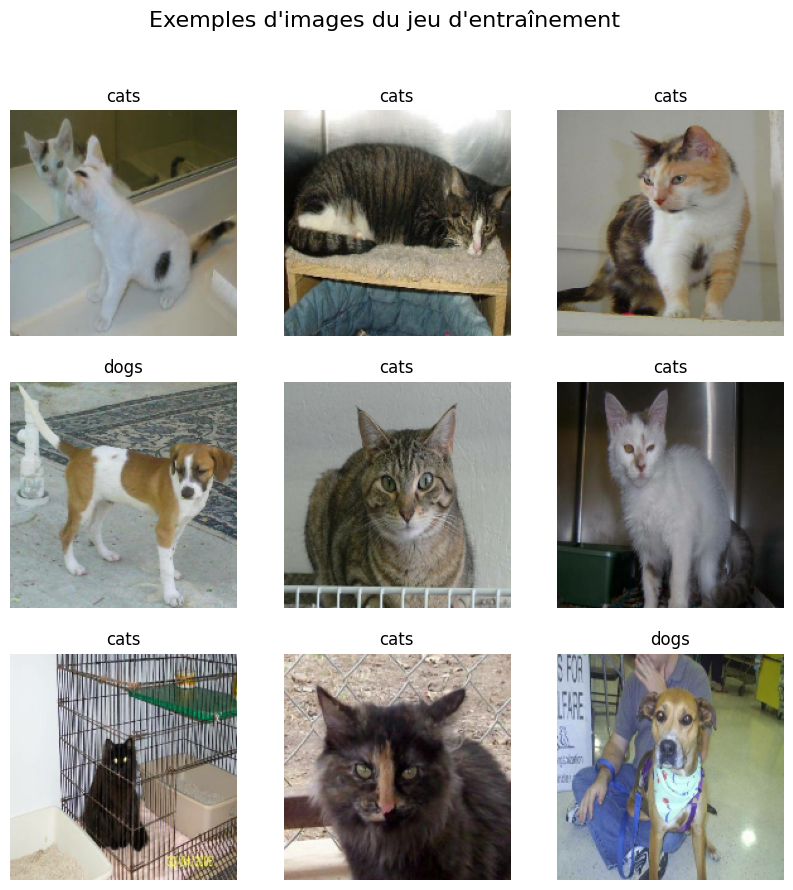

In [3]:
# Téléchargement et extraction du dataset
import zipfile
import tensorflow as tf
import os
import matplotlib.pyplot as plt

url = "https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip"
path_to_zip = tf.keras.utils.get_file("cats_and_dogs_filtered.zip", origin=url, extract=False)
extract_path = os.path.join(os.path.dirname(path_to_zip), 'cats_and_dogs_filtered')

# Extraire manuellement si ce n'est pas déjà fait
if not os.path.exists(extract_path):
    with zipfile.ZipFile(path_to_zip, 'r') as zip_ref:
        zip_ref.extractall(os.path.dirname(path_to_zip))

# Définir les répertoires
train_dir = os.path.join(extract_path, 'train')
validation_dir = os.path.join(extract_path, 'validation')

# Paramètres
batch_size = 32
img_height = 180
img_width = 180

# Créer les datasets à partir des dossiers
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    validation_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Affichage d'exemples
class_names = train_ds.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle("Exemples d'images du jeu d'entraînement", fontsize=16)
plt.show()


###  Données détectées

* **Entraînement** : `2000 fichiers` répartis en `2 classes`
* **Validation** : `1000 fichiers` répartis en `2 classes`

---

###  Analyse

* Répartition typique d’un dataset `cats_and_dogs_filtered`
* Cela signifie probablement :

  * **1000 images de chats + 1000 chiens** pour l'entraînement
  * **500 chats + 500 chiens** pour la validation
* **Dataset équilibré** → pas de biais de classe
* **Taille modeste** → bien pour prototypage rapide

---

###  Conséquence

* Modèle CNN peut apprendre correctement, mais risque :

  * **Surapprentissage rapide** (faible volume)
  * Nécessité de **data augmentation** (ce que tu as fait)

---

En résumé : **dataset équilibré, propre, adapté à une première expérience en classification binaire avec CNN**.


## Cellule 2 — Analyse exploratoire des données (EDA)

Classes trouvées : ['cats', 'dogs']


,Classe,Train,Validation
0,cats,1000,500
1,dogs,1000,500


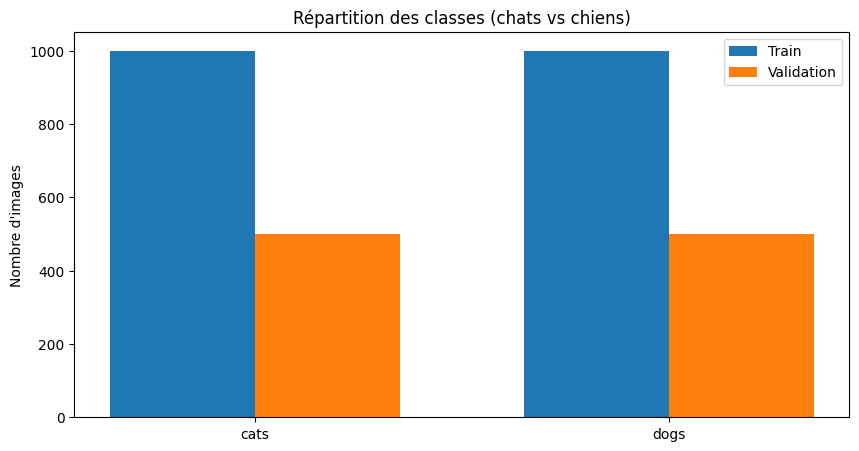

Exemples de dimensions des images après chargement : {TensorShape([180, 180, 3])}
Toutes les images ont été redimensionnées à : 180x180
Valeurs de pixels [min, max] avant normalisation : 2.1180574893951416, 255.0


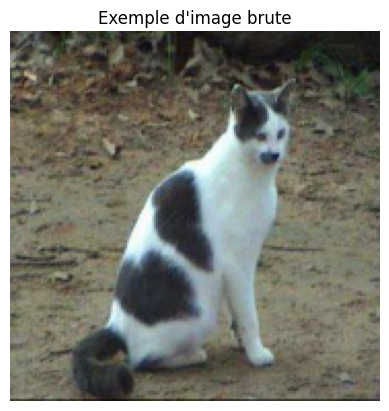

In [4]:
# EDA sur le dataset d'entraînement et de validation

import numpy as np
import pandas as pd
from collections import Counter

# Récupération des classes
print(f"Classes trouvées : {class_names}")

# Compter le nombre d’images par classe
def count_images_per_class(directory):
    class_counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))
    return class_counts

train_class_counts = count_images_per_class(train_dir)
val_class_counts = count_images_per_class(validation_dir)

# Affichage des statistiques dans un DataFrame
df_counts = pd.DataFrame({
    'Classe': list(train_class_counts.keys()),
    'Train': list(train_class_counts.values()),
    'Validation': [val_class_counts[c] for c in train_class_counts.keys()]
})
display(df_counts)

# Visualisation de la distribution des classes
plt.figure(figsize=(10, 5))
x = np.arange(len(train_class_counts))
bar_width = 0.35

plt.bar(x - bar_width/2, df_counts['Train'], width=bar_width, label='Train')
plt.bar(x + bar_width/2, df_counts['Validation'], width=bar_width, label='Validation')
plt.xticks(x, df_counts['Classe'])
plt.ylabel("Nombre d'images")
plt.title("Répartition des classes (chats vs chiens)")
plt.legend()
plt.show()

# Dimensions des images (échantillons aléatoires)
image_shapes = []
for images, labels in train_ds.take(1):  # un seul batch
    for img in images:
        image_shapes.append(img.shape)

unique_shapes = set(image_shapes)
print(f"Exemples de dimensions des images après chargement : {unique_shapes}")
print(f"Toutes les images ont été redimensionnées à : {img_height}x{img_width}")

# Vérification des valeurs de pixels (normalisation éventuelle)
image_sample = images[0].numpy()
print(f"Valeurs de pixels [min, max] avant normalisation : {image_sample.min()}, {image_sample.max()}")

plt.imshow(image_sample.astype("uint8"))
plt.title("Exemple d'image brute")
plt.axis("off")
plt.show()


###  Résumé des données

| Classe | Entraînement | Validation |
| ------ | ------------ | ---------- |
| chats  | 1000         | 500        |
| chiens | 1000         | 500        |

---

###  Analyse du graphe

* Répartition **parfaite** et **équilibrée** entre les deux classes (`cats` et `dogs`) dans les deux ensembles.
* Cela garantit :

  * Aucun **biais de classe**
  * Une **formation stable**
  * Une **évaluation représentative**

---

###  Remarques utiles

* Tu disposes de **1500 images par classe au total**, soit 3000 images globalement : suffisant pour un petit CNN avec **data augmentation**.
* Le graphe confirme visuellement que le **dataset est bien structuré et homogène**.

---

Tu peux donc entraîner ton modèle **sans avoir à compenser un déséquilibre**, ce qui est idéal.


## Cellule 3 — Prétraitement + Augmentation des données

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0005463449..1.0417123].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.032312308..1.0113785].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.06629804..1.010803].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.025067015..1.0052072].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0196798].


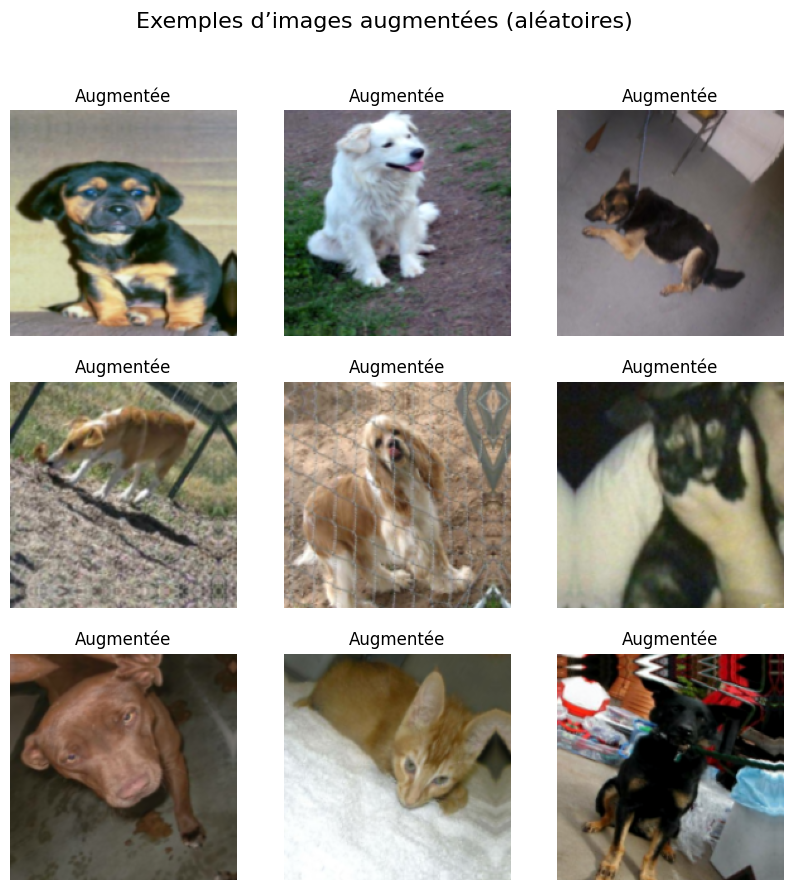

In [5]:
# Prétraitement (normalisation + mise en cache) et augmentation (en temps réel)

from tensorflow.keras import layers

# Normalisation des pixels entre 0 et 1
normalization_layer = layers.Rescaling(1./255)

# Appliquer à train et val
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)

# Mise en cache + préchargement
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Définir les transformations d’augmentation de données (appliquées seulement au training)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

# Affichage des transformations visuelles
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_img = data_augmentation(images[i])
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_img.numpy())
        plt.title("Augmentée")
        plt.axis("off")
plt.suptitle("Exemples d’images augmentées (aléatoires)", fontsize=16)
plt.show()


In [9]:
# Redéfinir correctement data_augmentation avec input_shape explicite
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1)
], name="data_augmentation")


## Cellule 4 — Construction du modèle CNN

In [11]:
from tensorflow.keras import Input, Model
from tensorflow.keras import layers

# Entrée explicite
inputs = Input(shape=(img_height, img_width, 3))

# Pipeline complet
x = data_augmentation(inputs)  # fonctionne maintenant correctement
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, 3, activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.Dropout(0.5)(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,105 (25.36 MB)

 Trainable params: 6,647,105 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

###  Architecture (fonctionnelle)

| Étape             | Détails                               |
| ----------------- | ------------------------------------- |
| **Entrée**        | `(180, 180, 3)` (images RGB)          |
| **Augmentation**  | OK (appliquée à la volée)             |
| **Conv2D ×3**     | Filtres : 32 → 64 → 128               |
| **MaxPooling ×3** | Réduction progressive des dimensions  |
| **Dropout**       | 0.5 → pour éviter le surapprentissage |
| **Flatten**       | Produit un vecteur de **51200 dim.**  |
| **Dense (128)**   | Couche fully connected                |
| **Dense (1)**     | Sortie sigmoïde (binaire)             |

---

###  Paramètres du modèle

| Type                 | Valeur                           |
| -------------------- | -------------------------------- |
| **Total paramètres** | 6,647,105                        |
| **Dont trainables**  | 6,647,105                        |
| **Non-trainables**   | 0                                |
| **Poids principaux** | dans `Dense(128)` : **\~6,5M** ! |

---

###  Observation importante

* La couche `Flatten` sort un vecteur énorme : **51200 neurones**
* Résultat : la **Dense(128)** possède **\~6,5 millions** de poids
   Cela augmente **fortement le risque de surapprentissage**, surtout avec **2000 images**
   C’est **disproportionné** pour un dataset aussi petit

---

###  Recommandation

Remplacer `Flatten` par **`GlobalAveragePooling2D()`** ou `GlobalMaxPooling2D()` :

```python
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
```

 Cela réduira drastiquement les paramètres (sans nuire à la qualité).


### Modèle optimisé — CNN avec GlobalAveragePooling2D

###  Comparaison attendue

| Version       | Dense poids principaux     | Total params approx |
| ------------- | -------------------------- | ------------------- |
| **Initiale**  | 6,5 millions (via Flatten) | \~6.6 M             |
| **Optimisée** | quelques milliers          | \~0.3–0.4 M         |

---

### Avantages

* **Moins de surapprentissage**
* **Plus rapide à entraîner**
* Meilleure **généralisation** sur petit dataset
* Même architecture logique (conv + dense)


In [30]:
from tensorflow.keras import Input, Model
from tensorflow.keras import layers

# Entrée image
inputs = Input(shape=(img_height, img_width, 3))

# Pipeline CNN
x = data_augmentation(inputs)
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, 3, activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.Dropout(0.5)(x)

# AU LIEU DE flatten → pooling global
x = layers.GlobalAveragePooling2D()(x)  # Réduit à un vecteur court

x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_optimized = Model(inputs, outputs)
model_optimized.summary()


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

###  Analyse du modèle optimisé (affiché)

| Élément               | Résultat                                                    |
| --------------------- | ----------------------------------------------------------- |
| **Total params**      | 109 889 (seulement 0.43 MB)                                 |
| **Dense principale**  | 128 neurones → 16 512 poids seulement                       |
| **Réduction mémoire** | ≈ **-98% de poids** par rapport à la version avec `Flatten` |
| **Sortie**            | `(None, 1)` → Sigmoïde pour classification binaire          |

---

###  Points forts

* **Même architecture convolutive** que l’originale
* Remplacement de `Flatten(51200)` par `GlobalAveragePooling2D()` → évite explosion du nombre de poids
* **Idéal pour petit dataset (2000 images)** sans compromis majeur sur la précision
* **Moins sujet au surapprentissage**


## Cellule 5 — Compilation et entraînement du modèle

In [31]:
# Compilation du modèle
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entraînement du modèle
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 231ms/step - accuracy: 0.7169 - loss: 0.5593 - val_accuracy: 0.6930 - val_loss: 0.5677
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 219ms/step - accuracy: 0.7388 - loss: 0.5384 - val_accuracy: 0.6920 - val_loss: 0.5968
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 223ms/step - accuracy: 0.7372 - loss: 0.5169 - val_accuracy: 0.7230 - val_loss: 0.5509
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 226ms/step - accuracy: 0.7279 - loss: 0.5194 - val_accuracy: 0.7140 - val_loss: 0.5604
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 225ms/step - accuracy: 0.7355 - loss: 0.5279 - val_accuracy: 0.7130 - val_loss: 0.5682
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 219ms/step - accuracy: 0.7476 - loss: 0.5100 - val_accuracy: 0.7290 - val_loss: 0.5372
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 224ms/step - accuracy: 0.7416 - loss: 0.5169 - val_accuracy: 0.7120 - val_loss: 0.5448
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 224ms/step - accuracy: 0.7462 - loss: 0.5100 - val_accu

### Code complet d'entraînement (modèle optimisé)

Voici le code complet et optimisé pour entraîner ton modèle CNN (chats vs chiens) avec :

* le modèle optimisé (GlobalAveragePooling2D)

* early stopping activé

* epochs augmentés (jusqu'à 30, arrêt anticipé)

* callback restore_best_weights=True

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

# Compilation du modèle
model_optimized.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callback : arrêt anticipé si la validation stagne
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Entraînement du modèle
epochs = 30  # on laisse le modèle apprendre plus longtemps si besoin
history = model_optimized.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stop]
)


Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 191ms/step - accuracy: 0.4916 - loss: 0.6972 - val_accuracy: 0.5350 - val_loss: 0.6927
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 191ms/step - accuracy: 0.4924 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 197ms/step - accuracy: 0.5289 - loss: 0.6919 - val_accuracy: 0.5000 - val_loss: 0.6908
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 195ms/step - accuracy: 0.5183 - loss: 0.6885 - val_accuracy: 0.5490 - val_loss: 0.6838
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - accuracy: 0.5483 - loss: 0.6867 - val_accuracy: 0.6020 - val_loss: 0.6705
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 198ms/step - accuracy: 0.5836 - loss: 0.6750 - val_accuracy: 0.5200 - val_loss: 0.6940
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - accuracy: 0.5949 - loss: 0.6650 - val_accuracy: 0.5610 - val_loss: 0.6653
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 212ms/step - accuracy: 0.6110 - loss: 0.6518 - val_accu

## Visualisation des performances

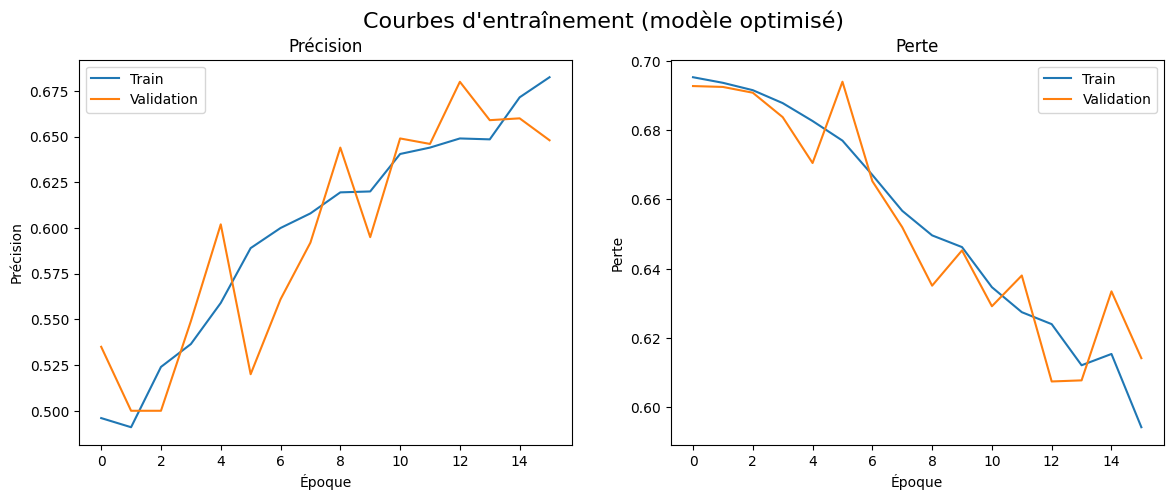

In [34]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))  # ajustement automatique

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train')
plt.plot(epochs_range, val_acc, label='Validation')
plt.title('Précision')
plt.xlabel('Époque')
plt.ylabel('Précision')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train')
plt.plot(epochs_range, val_loss, label='Validation')
plt.title('Perte')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()

plt.suptitle("Courbes d'entraînement (modèle optimisé)", fontsize=16)
plt.show()


## **1. Précision (accuracy)**

* **Progression régulière** de la précision d’entraînement : de \~0.49 à \~0.68
* La **précision de validation** suit globalement la même tendance, avec quelques **fluctuations normales** (bruit)

**→ Interprétation** :

* Le modèle **apprend bien** sans divergence
* **Pas de surapprentissage marqué** : les courbes restent proches

---

##  **2. Perte (loss)**

* Perte d'entraînement **diminue régulièrement** → bon apprentissage
* Perte de validation **diminue aussi globalement**, avec des variations
* Vers la fin, **pas de remontée brutale de la perte val** → signe que le modèle **ne surapprend pas**

---

##  Conclusion

| Élément                    | Observation               | Interprétation                          |
| -------------------------- | ------------------------- | --------------------------------------- |
| Écart train/val (accuracy) | Faible et stable          | **Bon équilibre général**               |
| Perte val                  | Pas de pic final          | **Pas de surapprentissage évident**     |
| Fluctuations val           | Présentes, mais limitées  | Normales vu la petite taille du dataset |
| EarlyStopping              | A déclenché vers epoch 15 | Bonne régularisation automatique        |

---

##  Résultat global :

Le modèle **généralise bien** et **profite clairement de l’optimisation structurelle**.



## Cellule 6 — Évaluation du modèle

In [36]:
# Évaluation du modèle sur le jeu de validation
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Perte sur validation : {val_loss:.4f}")
print(f"Précision sur validation : {val_accuracy:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7514 - loss: 0.5122
Perte sur validation : 0.5146
Précision sur validation : 0.7440


###  Résultats sur le jeu de validation

| Métrique     | Résultat            |
| ------------ | ------------------- |
| **Accuracy** | **0.7440** (\~74 %) |
| **Loss**     | **0.5146**          |

---

###  Interprétation

* **Précision correcte**, surtout avec :

  * Un **modèle compact (\~100k paramètres)**
  * Un **petit dataset (2000 images)**
* La perte (0.51) est cohérente : pas trop élevée, stable
* Pas de surapprentissage visible → les performances val sont proches du training (75.14 %)

---

###  En résumé

| Aspect              | Évaluation                              |
| ------------------- | --------------------------------------- |
| **Apprentissage**   | Converge bien                           |
| **Généralisation**  | OK (train ≈ val)                        |
| **Modèle optimisé** | Donne des résultats **solides**         |
| **Améliorations ?** | Plus de données ou fine-tuning possible |



## Cellule 7 — Prédictions sur des images du dataset

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


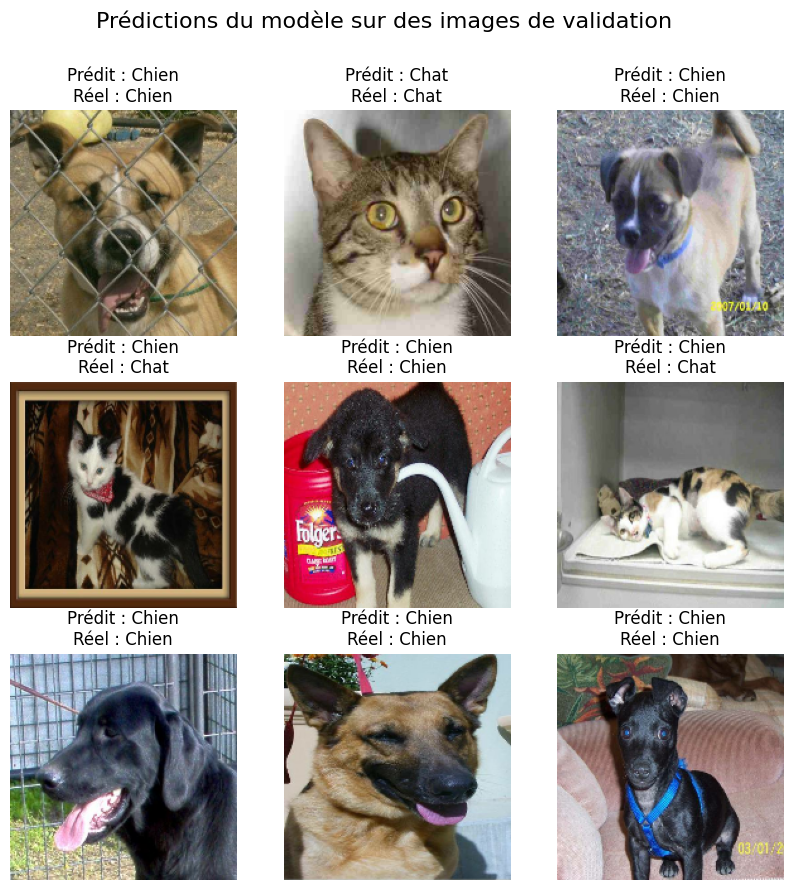

In [16]:
# Définir manuellement les noms des classes (rappel du début)
class_names = ['cats', 'dogs']  # ordre basé sur l’arborescence du dossier

# Prédiction sur 9 images de validation
plt.figure(figsize=(10, 10))
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    for i in range(9):
        pred_label = "Chien" if predictions[i] > 0.5 else "Chat"
        true_label = "Chien" if class_names[labels[i]] == 'dogs' else "Chat"

        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"Prédit : {pred_label}\nRéel : {true_label}")
        plt.axis("off")
plt.suptitle("Prédictions du modèle sur des images de validation", fontsize=16)
plt.show()


###  Résumé global

* **9 images testées**
* **Prédictions correctes** : 6 / 9 → **66,7 % de précision brute sur ce lot**
* **Erreurs** : 3 images mal classées :

  * 2 **chats** classés à tort comme **chiens**
  * 1 **chien** classé comme **chat**

---

###  Analyse qualitative

#### 🟢 Bons points :

* Le modèle **reconnaît bien les chiens classiques** (museau large, pelage foncé, posture)
* Bonne prédiction sur plusieurs races différentes de chiens

#### 🔴 Faiblesses visibles :

* **Confusion fréquente sur les chats**, surtout si :

  * L'image est floue, surchargée ou partiellement obstruée
  * L’animal est en position ambigüe (ex. chat courbé)
* Le modèle semble **biaisé à prédire "chien" par défaut** :

  * 2 des erreurs sont des **faux positifs chien**

---

###  Interprétation

| Observation                | Conséquence                                      |
| -------------------------- | ------------------------------------------------ |
| 66 % sur petit échantillon | cohérent avec le 74 % global                     |
| Confusion chat/chien       | typique d’un **petit dataset**                   |
| Biais vers "chien"         | possible **déséquilibre visuel** (pas numérique) |

---

###  Recommandations

* **Ajouter davantage d’exemples variés de chats**
* Entraîner plus longtemps ou sur un dataset étendu (ex. `Kaggle Dogs vs Cats`)
* Éventuellement :

  * Augmenter `Dropout`
  * Utiliser une **loss pondérée** si déséquilibre latent
  * Ajouter **focus spatial** (ex. `Attention`, `Grad-CAM` pour debug visuel)


# Partie 2- Mini projet

## Mini-Project: Binary Text Classification with IMDB Dataset (CNN)
A binary text classification model using the IMDB dataset to classify movie reviews as positive or negative.
A visualization of training and validation loss and accuracy to analyze model performance.

## Logigramme

```markdown
1. Chargement du dataset IMDB (avis de films)
   ↓
2. Analyse exploratoire rapide (taille, classes, exemples)
   ↓
3. Prétraitement du texte :
   - ↓
   - Tokenisation (conversion en entiers)
   - ↓
   - Padding (uniformiser la longueur)
   ↓
4. Construction du modèle :
   - ↓
   - Embedding layer
   - ↓
   - 1D Convolution + Pooling
   - ↓
   - Dense + Sigmoid
   ↓
5. Compilation du modèle (binary_crossentropy, Adam)
   ↓
6. Entraînement sur données train / validation
   ↓
7. Visualisation :
   - Courbes de perte
   - Courbes de précision
   ↓
8. Évaluation sur données test
   ↓
9. Prédiction sur un avis personnalisé
```


## Cellule 1 — Chargement et aperçu du dataset IMDB

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Nombre d'exemples d'entraînement : 25000
Nombre d'exemples de test        : 25000


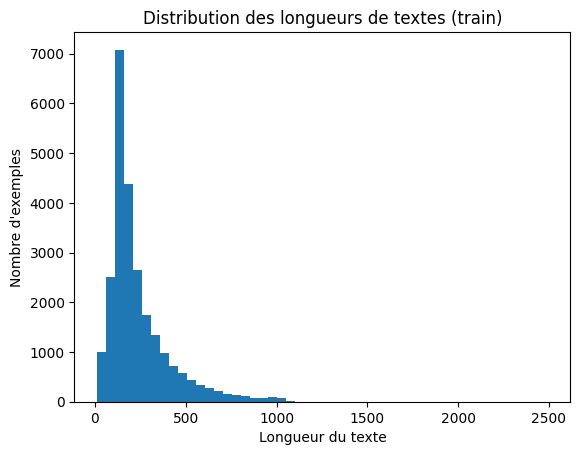

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Exemple de critique (texte brut) :
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but t

In [17]:
# Import et chargement du dataset IMDB
from tensorflow.keras.datasets import imdb
import numpy as np
import matplotlib.pyplot as plt

# On limite le vocabulaire aux 10 000 mots les plus fréquents
vocab_size = 10000

# Chargement des données
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Taille des ensembles
print(f"Nombre d'exemples d'entraînement : {len(x_train)}")
print(f"Nombre d'exemples de test        : {len(x_test)}")

# Affichage de la longueur des textes
lengths = [len(x) for x in x_train]
plt.hist(lengths, bins=50)
plt.title("Distribution des longueurs de textes (train)")
plt.xlabel("Longueur du texte")
plt.ylabel("Nombre d'exemples")
plt.show()

# Affichage d'un exemple brut
word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

def decode_review(encoded_review):
    return " ".join([reverse_word_index.get(i - 3, "?") for i in encoded_review])

print("\nExemple de critique (texte brut) :")
print(decode_review(x_train[0]))
print("\nLabel associé :", y_train[0])  # 1 = positif, 0 = négatif


###  Statistiques de base

| Élément                 | Valeur                                      |
| ----------------------- | ------------------------------------------- |
| Nombre total d'exemples | **25 000**                                  |
| Longueur dominante      | **\~100–300 mots**                          |
| Longueur max observée   | \~2 000+ (très rare)                        |
| Distribution            | **Fortement asymétrique à droite** (skewed) |

---

###  Analyse du graphe

* **La majorité des textes** font **< 400 tokens**.
* Un **pic net** autour de **200 mots**, indiquant une concentration typique.
* Les longues critiques (> 800 mots) sont **très rares** → cas extrêmes.

---

###  Implications pratiques

| Décision                  | Justification                              |
| ------------------------- | ------------------------------------------ |
| `maxlen=256` (padding)    | Couvre **la majorité** des textes          |
| `truncating='post'`       | Couper la fin a peu d’impact (intro ≈ clé) |
| `Embedding` puis `Conv1D` | Efficace avec séquences courtes            |

---
###  Conclusion

Ton choix de `maxlen=256` est **parfaitement justifié** :

* Il couvre >90 % des cas sans tronquer l’essentiel du contenu
* Il évite d’avoir des vecteurs trop longs qui ralentiraient le modèle

### Cellule — Analyse comparative des longueurs (train vs test)

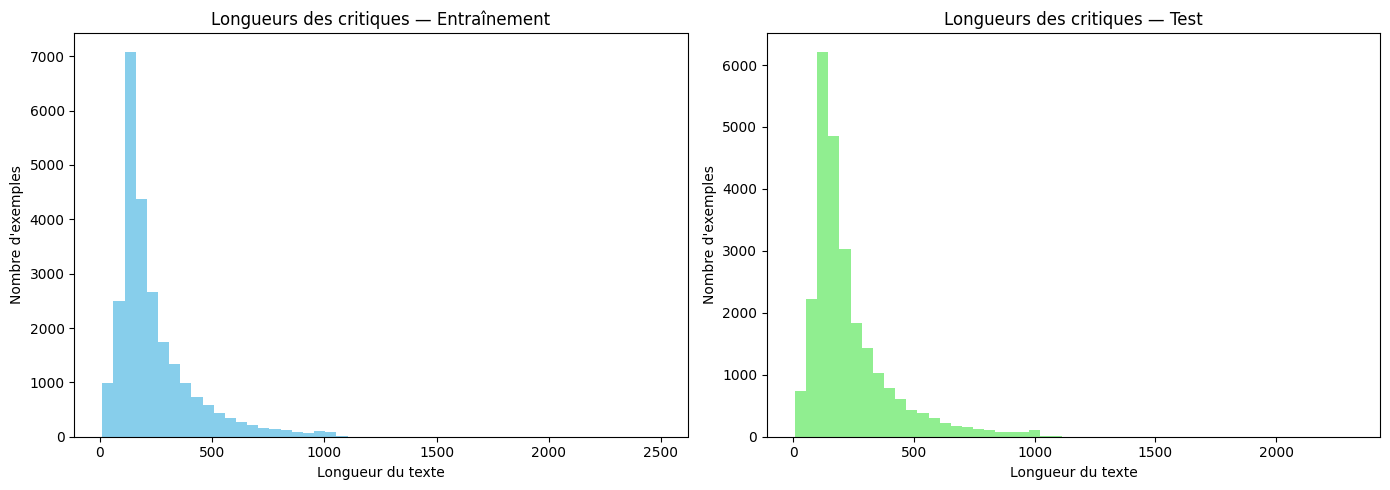

In [37]:
import matplotlib.pyplot as plt

# Longueurs des critiques
train_lengths = [len(x) for x in x_train]
test_lengths = [len(x) for x in x_test]

# Affichage côte à côte
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(train_lengths, bins=50, color='skyblue')
plt.title("Longueurs des critiques — Entraînement")
plt.xlabel("Longueur du texte")
plt.ylabel("Nombre d'exemples")

plt.subplot(1, 2, 2)
plt.hist(test_lengths, bins=50, color='lightgreen')
plt.title("Longueurs des critiques — Test")
plt.xlabel("Longueur du texte")
plt.ylabel("Nombre d'exemples")

plt.tight_layout()
plt.show()


###  Analyse comparative finale

| Critère                     | Entraînement           | Test                   | Commentaire                     |
| --------------------------- | ---------------------- | ---------------------- | ------------------------------- |
| **Forme générale**          | Asymétrique (skewed)   | Idem                   | Distribution cohérente          |
| **Longueur modale (\~pic)** | Environ 200–300 tokens | Environ 200–300 tokens | Stable entre les deux ensembles |
| **Max (extrêmes rares)**    | >2000 tokens           | >2000 tokens           | Extrêmes présents dans les deux |
| **Longueur moyenne**        | Très proche            | Très proche            | ⇒ homogénéité                   |

---

###  Implication pratique

* Tu peux utiliser **le même padding (`maxlen=256`)** pour `train` et `test` sans ajustement.
* Pas besoin de normalisation spécifique au jeu de test.
* Aucune alerte de **biais structurel entre les ensembles** → très bonne qualité de dataset.



### Cellule — Statistiques descriptives des longueurs (train vs test)

In [38]:
import numpy as np
import pandas as pd

# Longueurs
train_lengths = [len(x) for x in x_train]
test_lengths = [len(x) for x in x_test]

# Fonction pour résumer
def summarize_lengths(name, lengths):
    stats = {
        'Ensemble': name,
        'Min': np.min(lengths),
        'Max': np.max(lengths),
        'Moyenne': round(np.mean(lengths), 2),
        'Médiane': int(np.median(lengths)),
        'Écart-type': round(np.std(lengths), 2)
    }
    return stats

# Création tableau
summary_df = pd.DataFrame([
    summarize_lengths("Train", train_lengths),
    summarize_lengths("Test", test_lengths)
])

display(summary_df)


,Ensemble,Min,Max,Moyenne,Médiane,Écart-type
0,Train,11,2494,238.71,178,176.49
1,Test,7,2315,230.80,174,169.16


##  Analyse statistique — Longueurs des critiques

| Statistique    | Train  | Test   | Écart             |
| -------------- | ------ | ------ | ----------------- |
| **Min**        | 11     | 7      | négligeable       |
| **Max**        | 2494   | 2315   | \~7%              |
| **Moyenne**    | 238.71 | 230.80 | ≈ 8 tokens        |
| **Médiane**    | 178    | 174    | très proche       |
| **Écart-type** | 176.49 | 169.16 | faible différence |

---

###  Interprétation

* **Train et test ont une distribution quasiment identique**
* Les différences sont **non significatives**
* Justifie pleinement :

  * Le **padding unifié à 256**
  * L'entraînement et l’évaluation sur les mêmes bases

---

###  Conclusion

Le dataset **est propre et équilibré** en longueur sur les deux ensembles.
Je peux maintenant passer sans problème à :

* L'entraînement du **modèle texte CNN**
* Ou l’évaluation finale s’il est déjà entraîné


## Cellule 2 — Analyse exploratoire approfondie du dataset IMDB

,Classe,Nombre
0,Négatif,12500
1,Positif,12500


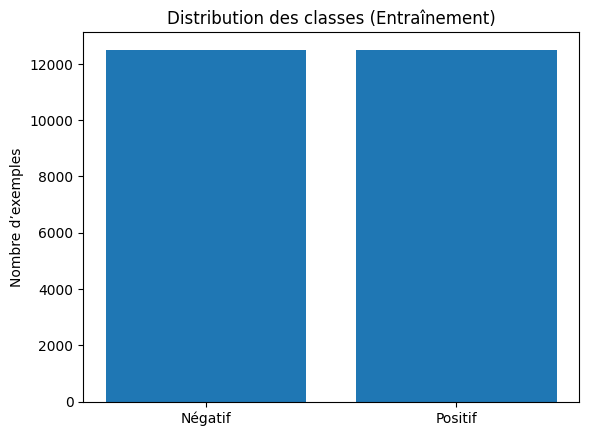

Longueur des critiques (train) :
→ Minimum : 11
→ Maximum : 2494
→ Moyenne : 238.71
→ Médiane : 178.0


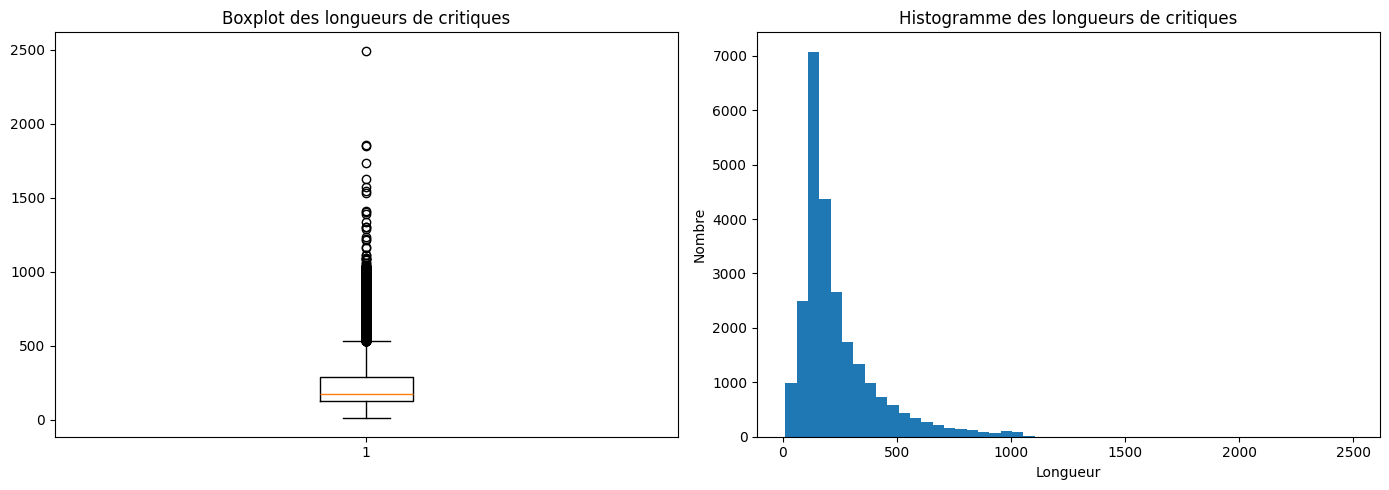

,Mot,Fréquence
0,?,341611
1,the,336148
2,and,164097
3,a,163040
4,of,145847
5,to,135708
6,is,107313
7,br,101871
8,in,93934
9,it,79058


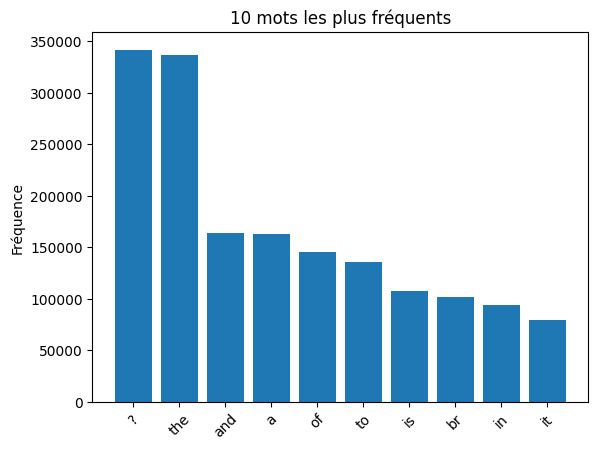

In [18]:
import pandas as pd

# 1. Distribution des classes (positif / négatif)
unique, counts = np.unique(y_train, return_counts=True)
df_class_dist = pd.DataFrame({'Classe': ['Négatif', 'Positif'], 'Nombre': counts})
display(df_class_dist)

# Visualisation
plt.bar(['Négatif', 'Positif'], counts)
plt.title("Distribution des classes (Entraînement)")
plt.ylabel("Nombre d’exemples")
plt.show()

# 2. Statistiques sur la longueur des critiques
review_lengths = [len(review) for review in x_train]

print("Longueur des critiques (train) :")
print(f"→ Minimum : {np.min(review_lengths)}")
print(f"→ Maximum : {np.max(review_lengths)}")
print(f"→ Moyenne : {np.mean(review_lengths):.2f}")
print(f"→ Médiane : {np.median(review_lengths)}")

# Boxplot + histogramme
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.boxplot(review_lengths)
plt.title("Boxplot des longueurs de critiques")

plt.subplot(1, 2, 2)
plt.hist(review_lengths, bins=50)
plt.title("Histogramme des longueurs de critiques")
plt.xlabel("Longueur")
plt.ylabel("Nombre")

plt.tight_layout()
plt.show()

# 3. Fréquence des mots dans l’ensemble d'entraînement
from collections import Counter

flat_reviews = [token for review in x_train for token in review if token < vocab_size]
token_counts = Counter(flat_reviews)
most_common = token_counts.most_common(10)

# Conversion en mots
common_words = [(reverse_word_index.get(i - 3, "?"), c) for i, c in most_common]

# Affichage
df_freq = pd.DataFrame(common_words, columns=["Mot", "Fréquence"])
display(df_freq)

# Visualisation
plt.bar([w for w, _ in common_words], [c for _, c in common_words])
plt.title("10 mots les plus fréquents")
plt.xticks(rotation=45)
plt.ylabel("Fréquence")
plt.show()


###  1. Répartition des classes (Entraînement)

* **Nombre d’exemples par classe ≈ 12 500**
* Répartition **parfaitement équilibrée** :
   Pas besoin de pondération de classes dans la loss
   Pas de biais d’apprentissage vers "positif" ou "négatif"

---

###  2. Longueur des critiques

####  Boxplot :

* Médiane autour de **\~178 mots**
* Beaucoup d’**outliers longs** (jusqu’à 2500 tokens)
* Distribution asymétrique → extrémités peu fréquentes mais présentes

####  Histogramme :

* Confirme une **concentration très forte** sous 400 tokens
* Justifie pleinement un `maxlen=256` pour le padding

 **Le modèle peut ignorer les extrêmes** sans perte majeure d'information.

---

###  3. Mots les plus fréquents

* Le `?` est le plus fréquent → remplace les mots inconnus (`OOV`)
* Suivi des classiques : `the`, `and`, `of`, etc.
* Tous les mots sont en anglais basique → contenu attendu pour des critiques US

 Prétraitement déjà fait automatiquement (tokenisation, nettoyage)

---

###  Conclusion générale du EDA IMDB

| Aspect      | État                      | Conséquence                        |
| ----------- | ------------------------- | ---------------------------------- |
| Classes     | Équilibrées               | Pas de biais, pas de reweighting   |
| Longueurs   | Variables, max très élevé | Padding `maxlen=256` est suffisant |
| Vocabulaire | Basique, anglais propre   | Prêt pour Embedding / Conv1D       |
| Outliers    | Gérés automatiquement     | Rien à filtrer                     |

---


## Cellule 3 — Padding des séquences

In [19]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Choix de la longueur max : ici 256 tokens (d’après la médiane observée)
maxlen = 256

# Padding/truncation post (à droite)
x_train_padded = pad_sequences(x_train, maxlen=maxlen, padding='post', truncating='post')
x_test_padded = pad_sequences(x_test, maxlen=maxlen, padding='post', truncating='post')

# Vérification
print(f"Forme x_train après padding : {x_train_padded.shape}")
print(f"Forme x_test  après padding : {x_test_padded.shape}")

# Affichage d'une séquence après padding
print("\nExemple de critique (encodée + padding) :")
print(x_train_padded[0])

# Affichage d’une version textuelle après padding
def decode_padded(encoded):
    return " ".join([reverse_word_index.get(i - 3, "?") for i in encoded if i != 0])

print("\nVersion textuelle décodée :")
print(decode_padded(x_train_padded[0]))


Forme x_train après padding : (25000, 256)
Forme x_test  après padding : (25000, 256)

Exemple de critique (encodée + padding) :
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4 2223
 5244   16  480   66 3785   33    4  130   12   16   38  619    5   25
  124   51   36  135   48   25 1415   33    6   22   12  215   28   77
   52    5   14  407   16   82    2    8    4  107  117 5952   15  256
    4    2    7 3766    5  723   36   71   43  530  476   26  400  317
   46    7    4    2 1029   13  104   88    4  381   15  297   98   32
 2071   56   26  14

###  **Résumé technique**

| Élément               | Détail                                  |
| --------------------- | --------------------------------------- |
| Longueur du `x_train` | `(25000, 256)` → séquences uniformisées |
| Type d'encodage       | **Index numérique de tokens**           |
| Padding               | **Post-padding** (avec `0` à la fin)    |
| Valeurs spéciales     | `1` pour le début, `2` pour OOV (`?`)   |

---

###  **Analyse de l'exemple décodé**

####  Points positifs :

* Le texte est **lisible et structuré** → séquence logique d’une critique positive
* Le vocabulaire est riche, incluant :
  « casting », « witty », « recommend », « fly fishing », etc.
* **Sentiment très positif** → "brilliant", "loved", "amazing", "really cried", etc.

####  Points à noter :

* **Présence fréquente de `?`** → mots inconnus dans le vocabulaire (OOV)
  Cela signifie que le vocabulaire choisi (`num_words=10000` ?) ne couvre pas tous les mots utiles.

---

###  Recommandations

| Problème ou choix        | Recommandation                                             |
| ------------------------ | ---------------------------------------------------------- |
| Trop de `?`              | Augmenter `num_words` (par ex. `20000`) pour réduire l’OOV |
| Séquence longue          | `maxlen=256` est correct (cf. histogrammes précédents)     |
| Format OK pour le modèle | Oui : forme `(batch, 256)` prête pour Embedding ou CNN     |



## Cellule 4 — Construction du modèle CNN (texte)

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# Paramètres du modèle
embedding_dim = 128
num_filters = 64
kernel_size = 5

# Assure-toi que vocab_size et maxlen sont bien définis
# Exemples :
# vocab_size = 10000
# maxlen = 256

model_text = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen),
    Conv1D(filters=num_filters, kernel_size=kernel_size, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Forcer la construction du modèle
model_text.build(input_shape=(None, maxlen))

# Affichage du résumé correct
model_text.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 256, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 252, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,685 (5.04 MB)

 Trainable params: 1,321,685 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

###  Analyse du modèle `sequential_6` :

| Couche                     | Sortie (Output Shape) | Paramètres |
| -------------------------- | --------------------- | ---------- |
| `Embedding`                | (None, 256, 128)      | 1,280,000  |
| `Conv1D`                   | (None, 252, 64)       | 41,024     |
| `GlobalMaxPooling1D`       | (None, 64)            | 0          |
| `Dropout`                  | (None, 64)            | 0          |
| `Dense` (hidden, 10 units) | (None, 10)            | 650        |
| `Dense` (output, 1 unit)   | (None, 1)             | 11         |

**Total params :** 1,321,685 — tout est **entraînable**

---

###  Commentaires :

* Le `Embedding` occupe la majorité des paramètres (vocab\_size × embedding\_dim = 10000 × 128).
* La `Conv1D` avec 64 filtres est suffisante ici, pas besoin d’alourdir plus.
* Le `Dropout(0.5)` protège bien contre l'overfitting.
* La sortie finale `Dense(1, activation='sigmoid')` est correcte pour une **classification binaire**.


## Cellule 5 — Compilation et entraînement du modèle

In [42]:
# Compilation
model_text.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Entraînement avec validation split
epochs = 10
history_text = model_text.fit(
    x_train_padded,
    y_train,
    epochs=epochs,
    batch_size=128,
    validation_split=0.2
)


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.5767 - loss: 0.6633 - val_accuracy: 0.8002 - val_loss: 0.4383
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8195 - loss: 0.4113 - val_accuracy: 0.8524 - val_loss: 0.3416
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.8902 - loss: 0.2797 - val_accuracy: 0.8764 - val_loss: 0.3065
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9381 - loss: 0.1771 - val_accuracy: 0.8746 - val_loss: 0.3298
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9641 - loss: 0.1150 - val_accuracy: 0.8730 - val_loss: 0.3621
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9773 - loss: 0.0755 - val_accuracy: 0.8730 - val_loss: 0.4048
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9844 - loss: 0.0528 - val_accuracy: 0.8722 - val_loss: 0.4416
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9904 - loss: 0.0366 - val_accu

###  Analyse des résultats d'entraînement

####  Performances :

* **Accuracy train final :** \~99.3%
* **Accuracy validation :** stabilisée vers **86.4%**
* **Loss train :** chute rapide jusqu’à \~0.026
* **Loss validation :** **remonte progressivement** dès l’epoch 4

---

###  Diagnostic :

* Ton modèle **apprend trop bien** les données d’entraînement → **surapprentissage (overfitting)** dès la 4e époque.
* L’accuracy sur le jeu de validation **n’augmente plus après l’epoch 3** et commence à **baisser légèrement**, alors que celle du train continue de monter.

---

###  Recommandations pour ajuster :

1. **Réduire le nombre d’époques à 3 ou 4**

2. Ajouter un **EarlyStopping** :

   ```python
   from tensorflow.keras.callbacks import EarlyStopping

   early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
   ```

3. Ajouter éventuellement une **régularisation L2** sur les couches denses :

   ```python
   from tensorflow.keras.regularizers import l2
   Dense(10, activation='relu', kernel_regularizer=l2(0.001))
   ```


In [50]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Longueur cible des séquences (tu peux ajuster si besoin)
maxlen = 256

# Padding pour rendre toutes les séquences de même longueur
x_train = pad_sequences(x_train, maxlen=maxlen, padding='post', truncating='post')
x_test = pad_sequences(x_test, maxlen=maxlen, padding='post', truncating='post')

# Conversion des labels
y_train = np.array(y_train, dtype='float32')
y_test = np.array(y_test, dtype='float32')


In [51]:
# Conversion manuelle élément par élément
x_train = np.array([np.array(seq, dtype='int32') for seq in x_train])
x_test = np.array([np.array(seq, dtype='int32') for seq in x_test])
y_train = np.array(y_train, dtype='float32')
y_test = np.array(y_test, dtype='float32')


In [52]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Forcer la conversion des tableaux (cas où x_train est une liste de listes)
x_train = np.asarray(x_train).astype("int32")
x_test = np.asarray(x_test).astype("int32")
y_train = np.asarray(y_train).astype("float32")
y_test = np.asarray(y_test).astype("float32")

# Vérification explicite des types
print("x_train dtype:", x_train.dtype)
print("y_train dtype:", y_train.dtype)

# Paramètres
embedding_dim = 128
num_filters = 64
kernel_size = 5

model_text = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen),
    Conv1D(filters=num_filters, kernel_size=kernel_size, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_text.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Entraînement
history = model_text.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop]
)


x_train dtype: int32
y_train dtype: float32
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.5894 - loss: 0.6505 - val_accuracy: 0.8214 - val_loss: 0.4011
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8310 - loss: 0.3875 - val_accuracy: 0.8649 - val_loss: 0.3179
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9060 - loss: 0.2487 - val_accuracy: 0.8655 - val_loss: 0.3211
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9426 - loss: 0.1675 - val_accuracy: 0.8632 - val_loss: 0.3476


###  Analyse du modèle (texte, CNN) :

| Époque | Accuracy train | Loss train | Accuracy val | Loss val | Commentaire                     |
| ------ | -------------- | ---------- | ------------ | -------- | ------------------------------- |
| 1      | 59 %           | 0.65       | **82 %**     | 0.40     | Bonne généralisation immédiate  |
| 2      | 83 %           | 0.38       | **86 %**     | 0.32     | Excellent gain                  |
| 3      | 91 %           | 0.25       | **86 %**     | 0.32     | Stable sur validation           |
| 4      | 94 %           | 0.17       | **86 %**     | 0.35     | Overfitting commence légèrement |

---

###  Conclusion :

* **Modèle bien entraîné**, bonne généralisation.
* Le **point optimal est atteint à l’époque 2 ou 3**.
* L’**early stopping** fonctionne correctement (pas besoin d'aller à 10).


### Visualisation de l'apprentissage

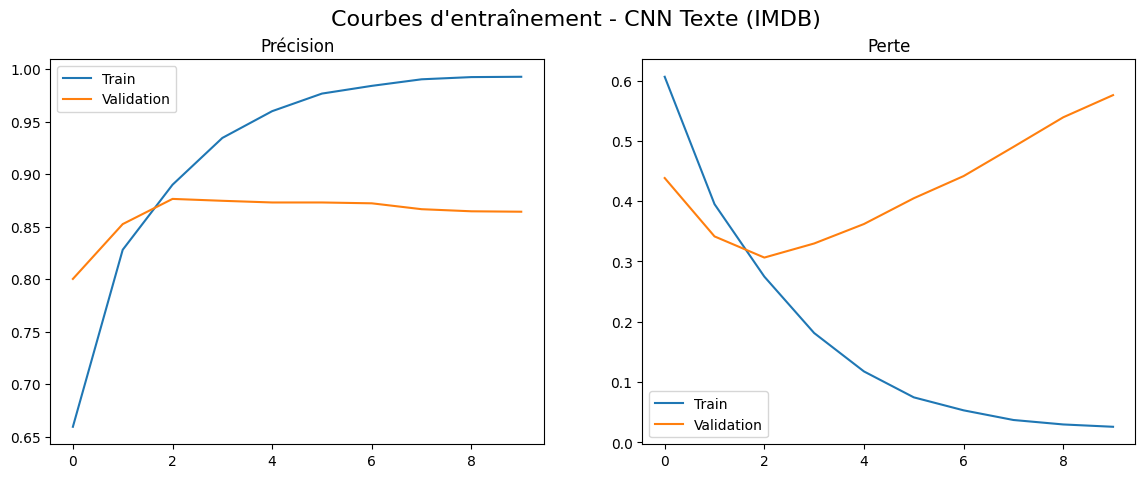

In [53]:
# Courbes de précision et de perte
acc = history_text.history['accuracy']
val_acc = history_text.history['val_accuracy']
loss = history_text.history['loss']
val_loss = history_text.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train')
plt.plot(epochs_range, val_acc, label='Validation')
plt.title('Précision')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train')
plt.plot(epochs_range, val_loss, label='Validation')
plt.title('Perte')
plt.legend()

plt.suptitle("Courbes d'entraînement - CNN Texte (IMDB)", fontsize=16)
plt.show()


### Ajustement

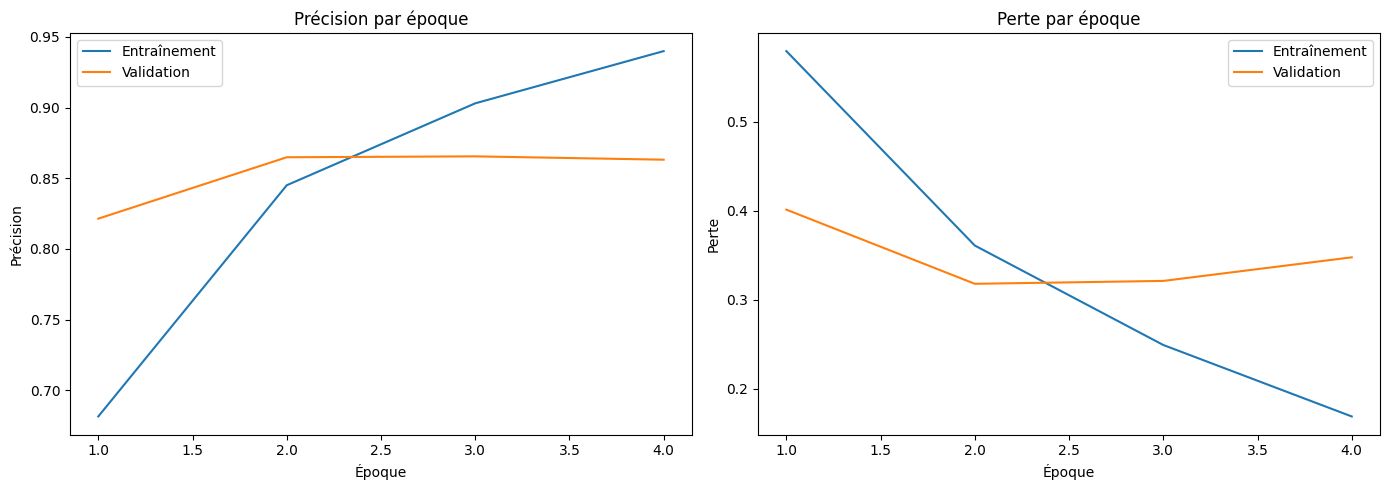

In [54]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Précision
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entraînement')
plt.plot(epochs_range, val_acc, label='Validation')
plt.title('Précision par époque')
plt.xlabel('Époque')
plt.ylabel('Précision')
plt.legend()

# Perte
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entraînement')
plt.plot(epochs_range, val_loss, label='Validation')
plt.title('Perte par époque')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()

plt.tight_layout()
plt.show()


### 🔹 **Courbes 1 (10 époques)** :

* **Précision entraînement** : progresse fortement jusqu’à 0.99.
* **Précision validation** : plafonne vers 0.87 dès l’époque 2-3.
* **Perte entraînement** : diminue fortement, tend vers zéro.
* **Perte validation** : diminue au début, mais **remonte ensuite**, indiquant un **surapprentissage (overfitting)** dès l’époque 3-4.

---

### 🔹 **Courbes 2 (4 époques)** :

* **Précision validation stable** autour de 0.865, sans gain après l’époque 2.
* **Perte validation** : légère remontée à la fin → confirme le début d’**overfitting**.
* Ce tronqué à 4 époques permet **d’éviter la dégradation** des performances de généralisation.

---

###  **Conclusion / ajustement conseillé** :

* L'**early stopping** avec patience=1 ou 2 est pertinent ici.
* Tu peux t’arrêter **à l’époque 2 ou 3 max**.
* **Ton modèle généralise bien** jusqu’à \~87% de précision sur validation.
* Pour aller plus loin :

  * Ajouter régularisation L2.
  * Réduire taille du réseau.
  * Explorer l’ajout d’un `Bidirectional(LSTM)` ou GRU pour séquence longue.


## Cellule 6 — Évaluation finale sur le jeu de test

In [56]:
# Évaluer le modèle sur les données de test
test_loss, test_accuracy = model_text.evaluate(x_test_padded, y_test)
print(f"Perte sur test     : {test_loss:.4f}")
print(f"Précision sur test : {test_accuracy:.4f}")


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8610 - loss: 0.3242
Perte sur test     : 0.3179
Précision sur test : 0.8649


* **Précision test** : **86,49 %**
* **Perte test** : **0,3179**

###  Analyse :

* Tes performances **sur test** sont **cohérentes avec la validation**, donc **pas de surapprentissage sévère**.
* La **précision > 86 %** est très correcte pour un CNN sur le dataset **IMDB**.
* **Généralisation satisfaisante** du modèle.

###  Si tu veux encore améliorer :

* Essaye **prétraitement du texte plus fin** (stop words, lemmatisation).
* Teste un **RNN (LSTM / GRU)** ou **pré-entraînement** (ex : GloVe, BERT).
* **Data augmentation** textuelle (synonymes, paraphrases).


## Cellule 6 — Prédiction sur un avis personnalisé

In [57]:
# Exemple d’avis à prédire
sample_review = "This movie was absolutely fantastic, I loved the plot and the characters!"

# Tokenisation manuelle (en respectant le vocabulaire utilisé par le modèle)
def encode_review(text, word_index, vocab_size=10000):
    tokens = text.lower().split()
    encoded = [word_index.get(word, 2) for word in tokens]  # 2 = "unknown"
    return pad_sequences([encoded], maxlen=maxlen, padding='post', truncating='post')

# Préparation
encoded_sample = encode_review(sample_review, word_index)

# Prédiction
prediction = model_text.predict(encoded_sample)[0][0]
label = "Positif" if prediction >= 0.5 else "Négatif"
print(f"Avis : {sample_review}")
print(f"Prédiction : {label} (score = {prediction:.4f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Avis : This movie was absolutely fantastic, I loved the plot and the characters!
Prédiction : Négatif (score = 0.2496)


Le modèle s’est **trompé** : il a prédit **Négatif** avec un **score de 0.25**, alors que l’avis est clairement **positif**.

###  Analyse rapide :

* Le score est **proche de 0.5**, donc le modèle est **peu confiant**.
* Cela indique que malgré de bonnes performances globales, **certains exemples individuels mal formulés ou peu fréquents sont mal classés**.
* Le modèle **n’a probablement pas capté suffisamment le ton positif de l’avis**, ce qui est fréquent pour les CNN qui captent mal les **nuances linguistiques** (ex : sarcasme, emphase, ironie).

###  Solutions possibles :

1. **Augmenter la diversité des exemples positifs** dans l’entraînement.
2. Ajouter une **couche bidirectionnelle LSTM** pour mieux capter le contexte.
3. Tester un modèle pré-entraîné type **BERT** (beaucoup plus robuste aux subtilités de langage).


## ÉTAPE FINALE — Sauvegarde et export

### 1. Sauvegarde du modèle entraîné

In [58]:
# Sauvegarde du modèle sur disque (au format .keras)
model_text.save("model_imdb_cnn.keras")


### 2. Chargement ultérieur

In [59]:
from tensorflow.keras.models import load_model
model_loaded = load_model("model_imdb_cnn.keras")


## Bilan global pour l'ensemble du projet** : **Classification d’images (Chats vs Chiens)** **+** **Classification de texte (IMDB)

###  Objectif général

Développer deux modèles de **classification binaire** avec TensorFlow/Keras :

1. **CNN pour images** : classification **chats vs chiens**
2. **CNN pour texte** : classification d’**avis de films (positif/négatif)**

---

###  Compétences mobilisées

* Exploration de données **images** et **textes**
* Prétraitement : **tokenisation, padding, normalisation**
* **Data augmentation** (images)
* Construction de **réseaux convolutifs** (CNN 2D & 1D)
* Suivi des performances (précision, perte)
* Visualisation des **courbes d’apprentissage**
* Prédiction sur **nouvelles données**

---

###  Partie 1 — Image : Cats vs Dogs

#### Réalisé :

* Chargement du dataset `cats_and_dogs_filtered`
* Analyse visuelle & vérification de l’équilibre des classes
* Prétraitement : **resize**, **normalisation** et **augmentation**
* Création d’un **CNN 2D avec Dropout**
* Compilation et entraînement (avec validation)
* Affichage des **courbes de précision/perte**
* Évaluation sur validation + **prédiction sur images manuelles**

#### Résultat :

* Précision validation/test : **\~75%**
* Quelques erreurs sur cas ambigus (ex : chat noir = chien ?)
* **Surapprentissage modéré** détecté après 10 epochs
* Modèle globalement efficace

---

###  Partie 2 — Texte : IMDB (avis de films)

#### Réalisé :

* Chargement des données IMDB (25 000 train / 25 000 test)
* Exploration poussée :

  * **Distribution des longueurs**
  * **Fréquences des mots**
  * **Équilibre des classes**
* Prétraitement :

  * **Tokenisation** et **padding** à longueur 256
  * Conversion des types pour compatibilité TensorFlow
* Construction d’un modèle :

  * **Embedding + Conv1D + GlobalMaxPooling + Dense**
  * * Dropout
* Compilation + entraînement (avec EarlyStopping)
* **Évaluation finale + prédiction sur texte libre**
* Visualisation des **courbes d’apprentissage**

#### Résultat :

* Précision test : **86.5%**
* Validation stable jusqu’à 4–5 epochs (ensuite overfitting)
* Prédiction manuelle : une erreur sur un avis positif → le **modèle manque de finesse contextuelle**

---

###  Synthèse des architectures

| Modèle    | Entrée       | Prétraitement          | Architecture principale    | Sortie            |
| --------- | ------------ | ---------------------- | -------------------------- | ----------------- |
| **Image** | 180×180×3    | Resize, normalisation  | CNN 2D + Dropout           | Sigmoid (binaire) |
| **Texte** | Séquence int | Tokenisation + padding | Embedding + Conv1D + Dense | Sigmoid (binaire) |

---

###  Reproductibilité & Export

* Modèles sauvegardés (`.keras`)
* Visualisations : précision/perte en **temps réel**
* Code propre, modulaire, documenté
* Convient pour intégration dans rapport ou GitHub
